# Multistart Optimization and Profile Likelihood with ParmEst

### Why Multistart?

Parameter estimation problems are often **nonconvex**, meaning that the objective function  
$g(\boldsymbol{x}, \boldsymbol{y};\boldsymbol{\theta})$ may contain multiple local minima.  
As a result, the solution obtained by a nonlinear optimization solver can depend strongly  
on the initial guess for $\boldsymbol{\theta}$.

Multistart optimization is a practical strategy to address this challenge. Instead of solving  
the problem once from a single initial point, we solve it multiple times from different  
initializations and compare the resulting solutions.

This approach helps:
- Increase the likelihood of identifying a **global or near-global optimum**
- Assess the **robustness** of parameter estimates
- Explore the **structure of the objective landscape**

---

### Multistart in ParmEst

The multistart functionality in `parmest` automates this process by generating multiple  
initial guesses for $\boldsymbol{\theta}$ within user-defined bounds and solving the  
parameter estimation problem repeatedly.

Initial points are sampled between predefined lower and upper bounds using one of the following methods:

- **Uniform random sampling**
- **Latin hypercube sampling (LHS)**
- **Sobol sequence sampling**

Each sampled point defines a new initialization of $\boldsymbol{\theta}$, and the optimization  
problem is solved independently for each case.

---

### Workflow Overview

A typical multistart workflow in ParmEst consists of:

1. Defining the parameter estimation model in Pyomo  
2. Specifying bounds for $\boldsymbol{\theta}$  
3. Selecting a sampling strategy and number of samples  
4. Solving the optimization problem for each sampled initialization  
5. Analyzing the distribution of solutions and objective values 

## Import packages

In [14]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load and explore experimental data

In [15]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


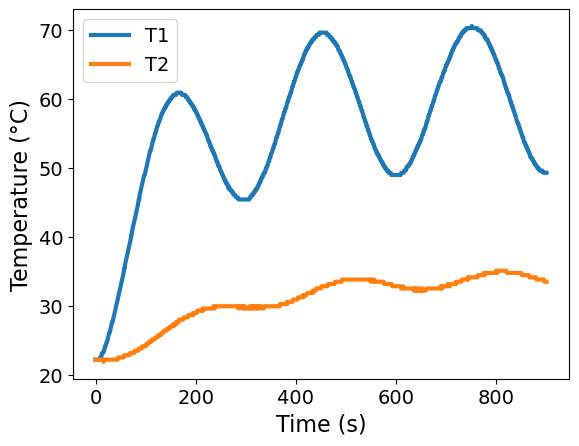

In [16]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

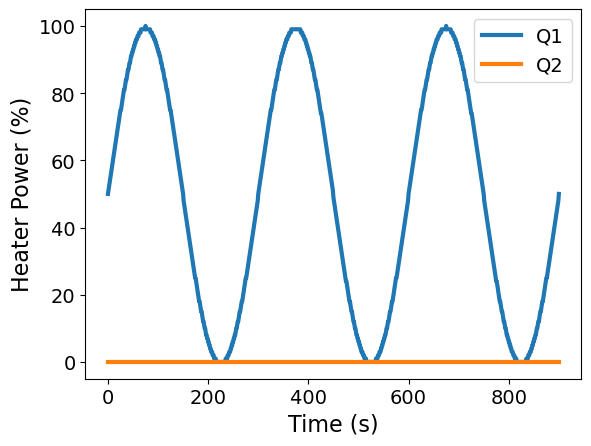

In [17]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

## Store in Custom Data Class 

In the file `tclab_pyomo.py`, we defined a `dataclass` for convenience. It is essentially a light weight container to store experimental data.

In [18]:
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values,
    T1=df['T1'].values,
    u1=df['Q1'].values,
    P1=200,
    TS1_data=None,
    T2=df['T2'].values,
    u2=df['Q2'].values,
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

In [19]:
tc_data.to_data_frame().head()

,time,T1,u1,P1,TS1_data,T2,u2,P2,TS2_data,Tamb
0,0.00,22.2,50,200,None,22.2,0,200,None,22.2
1,1.01,22.2,51,200,None,22.2,0,200,None,22.2
2,2.01,22.2,52,200,None,22.2,0,200,None,22.2
3,3.00,22.2,53,200,None,22.2,0,200,None,22.2
4,4.01,22.2,54,200,None,22.2,0,200,None,22.2


## Parameter Estimation with ParmEst

We seek to solve minimize the sum of residuals squared:

$$
\begin{align*}
\min_{C_p^H, C_p^S, U_a, U_b} \sum_{i \in \mathcal{T}} \left(T_{S}(t_i) - \bar{T}_{S,i} \right)^2
\end{align*}
$$

subject to constraints

$$
\begin{align*}
C_p^H \frac{dT_H}{dt} & = U_a (T_{amb} - T_H) + U_c (T_S - T_H) + \alpha P u(t)\\
C_p^S \frac{dT_S}{dt} & = - U_b (T_S - T_H)  \\
\\
\text{control input data}\qquad u(t_i) & = \bar{u}_{i}, \forall i \in \mathcal{T}
\\
\text{initial condition}\qquad T_H(t_0) & = T_{amb} \\
\text{initial condition}\qquad T_S(t_0) & = T_{amb}
\end{align*}
$$

Here $\bar{T}_{S,i}$ and $\bar{u}_i$ are the measured sensor temperatures and control signals, respectives, at times $i \in \mathcal{T}$. $w$ is a small weight that helps regularize the solution by preventing the model predictions $T_H$ from deviating too much from the measured temperatures.


In the `tclab_pyomo.py` model, we defined several helper functions:
* `extract_results` takes a Pyomo model and returns the results stored in an instance of the `TC_Lab_data` dataclass.
* `extract_plot_results` takes experimental data (stored in a `TC_Lab_data` instance) and a Pyomo model. The function then generates plots showing the data and model predictions.
* `results_summary` summarizes the Pyomo.DoE results. We'll use this later in the workshop.

`parmest` has been refactored to allow users to directly ask for the sum of squared error (SSE) objective. Custom objectives can also be provided, but are outside the scope of this workshop.

In [20]:
import pyomo.contrib.parmest.parmest as parmest

# First, we define an Experiment object within parmest
TC_Lab_sine_exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states)

solver_options = {
                  'linear_solver': 'ma57', 
                  'max_iter': 1000
                  }
# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
pest = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', tee=True, solver_options=solver_options)

results_df, best_theta, best_obj = pest.theta_est_multistart(
        n_restarts=10,
        seed=532,
        save_results=False,

)

WARNING (W1002): Setting Var 'Th1[439.01]' to a numeric value
`85.0826992396814` outside the bounds (0, 85).
    See also https://pyomo.readthedocs.io/en/latest/errors.html#w1002
WARNING (W1002): Setting Var 'Th1[440.01]' to a numeric value
`85.17910951486755` outside the bounds (0, 85).
    See also https://pyomo.readthedocs.io/en/latest/errors.html#w1002
WARNING (W1002): Setting Var 'Th1[441.01]' to a numeric value
`85.27196022452272` outside the bounds (0, 85).
    See also https://pyomo.readthedocs.io/en/latest/errors.html#w1002
WARNING (W1002): Setting Var 'Th1[442.01]' to a numeric value
`85.36125514423146` outside the bounds (0, 85).
    See also https://pyomo.readthedocs.io/en/latest/errors.html#w1002
WARNING (W1002): Setting Var 'Th1[443.01]' to a numeric value
`85.44699848093657` outside the bounds (0, 85).
    See also https://pyomo.readthedocs.io/en/latest/errors.html#w1002
WARNING (W1002): Setting Var 'Th1[444.0]' to a numeric value
`85.52837903316869` outside the bounds (

Let's see how to access the regression results:

In [21]:
best_theta_values = best_theta
print("Estimated parameters:\n", best_theta_values)

best_obj_value = best_obj
print("Best objective function value:", best_obj_value)

Estimated parameters:
 {'Ua': 0.04170517335773623, 'Ub': 0.017069641466311625, 'inv_CpH': 0.17070427829950383, 'inv_CpS': 3.136924106476991}
Best objective function value: 53.77399284580854


In [22]:
# View full results DataFrame from multistart estimation. Uncomment the line below to print the full results DataFrame to the terminal.
# print(results_df)

In [23]:
# Compare to different multistart sampling method (latin hypercube sampling)
pest_lhs = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', tee=True, solver_options=solver_options)
results_df_lhs, best_theta_lhs, best_obj_lhs = pest_lhs.theta_est_multistart(
        n_restarts=10,
        multistart_sampling_method="latin_hypercube",
        seed=532,
        save_results=False,

)

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific

In [24]:
best_theta_values = best_theta_lhs
print("Estimated parameters:\n", best_theta_values)

best_obj_value = best_obj_lhs
print("Best objective function value:", best_obj_value)

Estimated parameters:
 {'Ua': 0.04170517335763511, 'Ub': 0.01710739829117481, 'inv_CpH': 0.17072957175872755, 'inv_CpS': 3.1295370615161358}
Best objective function value: 53.77399284580887


## Profile Likelihood for Estimability Analysis

After estimating parameter values, it is important to assess whether those
parameters are supported by the available experimental data. In other words,
we would like to understand not only which parameter values minimize the
objective function, but also how much confidence we should have in those
values.

Two related concepts are especially important in parameter estimation:

1. **Identifiability**

    A parameter is identifiable if it can, in principle, be uniquely determined
    from ideal noise-free data and the specified model structure.

    Structural identifiability is a property of the model itself. If a parameter
    is structurally unidentifiable, then no amount of additional data from the
    same experimental setup will allow that parameter to be uniquely estimated.

2. **Estimability**

    A parameter is estimable if it can be reliably estimated from the available
    finite, noisy experimental data.

    Practical estimability depends on the model, the data, the measurement noise,
    and the experimental design. A parameter may be structurally identifiable but
    still difficult to estimate in practice if the data are not sufficiently
    informative.

In this workshop, we focus on practical estimability. We assume that the model
has been specified and that experimental data are available, and we ask whether
the data contain enough information to estimate each parameter with reasonable
confidence.

---

### Profile Likelihood

Profile likelihood is a useful tool for analyzing parameter estimability. The
main idea is to examine how much the objective function increases when one
parameter is fixed at values away from its estimated optimum, while all other
parameters are re-estimated.

Let $\hat{\boldsymbol{\theta}}$ be the parameter estimate obtained by solving

$$
   \hat{\boldsymbol{\theta}}
   =
   \arg\min_{\boldsymbol{\theta}}
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
$$

where $g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})$ is the parameter
estimation objective function.

For a parameter $\theta_j$, the profile likelihood is constructed by fixing
$\theta_j$ at a specified value and re-solving the parameter estimation problem
over the remaining parameters:

$$
   g_{\text{profile}}(\theta_j)
   =
   \min_{\boldsymbol{\theta}_{-j}}
   g(\boldsymbol{x}, \boldsymbol{y}; \theta_j, \boldsymbol{\theta}_{-j})
$$

where $\boldsymbol{\theta}_{-j}$ denotes the vector of all parameters except
$\theta_j$.

By repeating this calculation over a range of fixed values for $\theta_j$, we
obtain a profile that describes how sensitive the objective function is to
changes in that parameter.

---

### Interpreting Profile Likelihoods

The shape of the profile likelihood provides information about parameter
estimability.

If the profile likelihood increases sharply as $\theta_j$ moves away from its
estimated value, then the data strongly constrain that parameter. In this case,
$\theta_j$ is practically estimable.

If the profile likelihood is relatively flat over a wide range of values, then
many different values of $\theta_j$ provide similar agreement with the data. In
this case, $\theta_j$ may be practically non-estimable.

If the profile likelihood does not increase sufficiently in one or both
directions, then the data may only provide a one-sided bound or no meaningful
bound on the parameter.

Typical qualitative interpretations are:

- A **narrow profile** indicates that the parameter is well constrained by the data.
- A **wide profile** indicates that the parameter is weakly constrained by the data.
- A **flat profile** indicates that the parameter may be practically non-estimable.
- A **profile with a boundary** may indicate that the parameter is only bounded
  on one side or that the chosen parameter bounds affect the result.

---

### Confidence Regions from Profile Likelihood

Profile likelihood can also be used to approximate confidence intervals for
individual parameters. For a least squares objective, a confidence threshold can
be defined relative to the optimal objective value:

$$
   g_{\text{profile}}(\theta_j)
   \leq
   g(\boldsymbol{x}, \boldsymbol{y}; \hat{\boldsymbol{\theta}})
   +
   \Delta
$$

where $\Delta$ is selected based on the desired confidence level.

Parameter values that satisfy this inequality are considered plausible given
the data and model. The corresponding interval gives an approximate confidence
interval for $\theta_j$.

If this interval is finite and reasonably narrow, then the parameter is
estimable from the available data. If the interval is very wide or extends to
the parameter bounds, then the parameter may not be practically estimable.

---

### Estimability Analysis Workflow

A typical profile likelihood workflow consists of:

1. Solving the parameter estimation problem to obtain
   $\hat{\boldsymbol{\theta}}$
2. Selecting one parameter $\theta_j$ to profile
3. Fixing $\theta_j$ at values above and below its estimated value
4. Re-solving the optimization problem over the remaining parameters
5. Plotting the profile likelihood as a function of $\theta_j$
6. Comparing the profile to a confidence threshold
7. Repeating the process for each parameter of interest

This process allows us to determine which parameters are well supported by the
current data and which parameters may require additional experiments, improved
measurements, or model reformulation.

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific

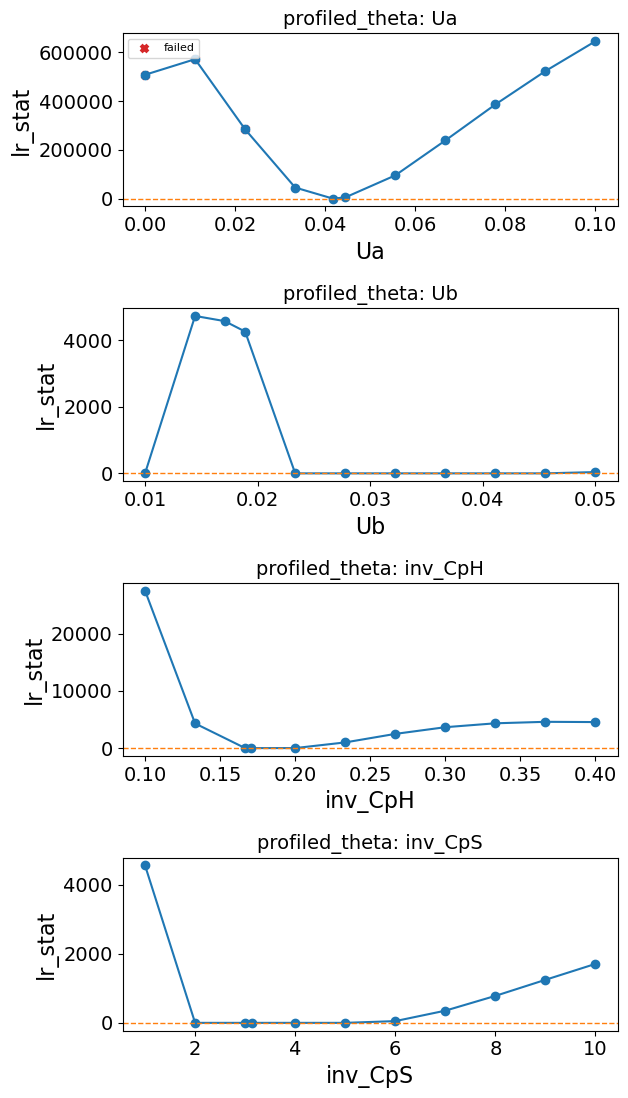

In [ ]:
# Do profile likelihood estimation to construct confidence intervals for the parameters. 
# This is a more robust method for constructing confidence intervals, 
# as it does not rely on the assumption of normality in the parameter estimates.

# Compute profile likelihood for both unknown parameters.
# Use a small grid for quick terminal runs.
profile_results = pest.profile_likelihood(
    profiled_theta=["Ua", "Ub", "inv_CpH", "inv_CpS"],
    n_grid=20,
    solver="ef_ipopt",
    warmstart="neighbor",
)

# Display a compact summary table
profiles = profile_results["profiles"]
print("\nBaseline:")
print(profile_results["baseline"])
print("\nProfile results (first 12 rows):")
print(
    profiles[
        [
            "profiled_theta",
            "theta_value",
            "obj",
            "delta_obj",
            "lr_stat",
            "status",
            "success",
        ]
    ].head(12)
)

# Plot profile curves to file for terminal/non-GUI usage
parmest.graphics.profile_likelihood_plot(
    profile_results, alpha=0.95, 
)


In [26]:
# Uncomment the line below to print the full profile results DataFrame to the terminal.
# print(profile_results)

## Activity: Discuss profile likelihood results above with a neighbor.

Take 2 minutes. From the profile likelihood results:

- Which parameter(s) are estimable?
- Which parameter(s) are inestimable?
- What are possible next steps to improve the estimability?
